# Multi-Asset Regime Analysis and Risk-Controlled Strategy

This project covering market regime classification, strategy design, stress handling, AI transparency.
The analysis uses daily data for BTC, ETH, Gold, the S&P 500, and the US 10Y yield.


## What This Project Does

1. Loads and aligns the five asset files.
2. Computes daily log returns, rolling volatility, cross-asset correlations, and regime signals.
3. Classifies four investable states: `Risk-On Momentum`, `Transition`, `Defensive Risk-Off`, and `Liquidity Stress`.
4. Simulates a risk-controlled core strategy with an opportunistic de-risking overlay.
5. Produces charts, tables, and short written sections for the non-code parts of the project.

The goal is not to maximize raw return. The goal is to show disciplined decision-making under institutional constraints: limited leverage, daily liquidity, execution efficiency, and a hard drawdown ceiling.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_FILES = {
    "BTC": "BTCUSDT_2020_2025.csv",
    "ETH": "ETHUSDT_2020_2025.csv",
    "Gold": "OANDA_XAUUSD_2020_2025.csv",
    "SP500": "SP500_2020_2025.csv",
    "US10Y": "US10Y_2020_2025.csv",
}

STARTING_CAPITAL = 10_000_000
TARGET_VOL = 0.09
HARD_RISK_BRAKE = -0.08


In [2]:
def load_close_series(asset, filename):
    path = Path(filename)
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {filename}")

    df = pd.read_csv(path, parse_dates=["date"])
    df.columns = [str(col).strip() for col in df.columns]
    if "close" not in df.columns:
        raise ValueError(f"{filename} does not contain a 'close' column.")

    out = df[["date", "close"]].copy()
    out = out.rename(columns={"close": asset})
    return out


frames = [load_close_series(asset, filename) for asset, filename in DATA_FILES.items()]

market = frames[0]
for frame in frames[1:]:
    market = market.merge(frame, on="date", how="inner")

market = market.sort_values("date").set_index("date")
prices = market[["BTC", "ETH", "Gold", "SP500"]].copy()
rates = market["US10Y"].copy()

market.tail()


,BTC,ETH,Gold,SP500,US10Y
date,,,,,
2025-12-27,87829.4,2947.61,4533.210,6933.73,4.132
2025-12-28,87920.5,2949.60,4533.210,6933.73,4.132
2025-12-29,87203.3,2936.45,4332.560,6915.20,4.112
2025-12-30,88455.3,2972.22,4339.395,6904.70,4.126
2025-12-31,87608.2,2970.40,4322.610,6854.40,4.163


## Part 1: Regime Framework

The classification logic focuses on variables that are interpretable and statistically testable.

**Variables used**

- `20d` and `60d` simple returns for BTC, ETH, Gold, and the S&P 500.
- `20d` realized volatility for BTC and ETH, using daily log returns annualized by `sqrt(252)`.
- `20d` rolling correlation between BTC and the S&P 500 as a proxy for cross-asset contagion.
- `20d` Gold-minus-S&P relative return as a simple flight-to-safety check.
- `20d` change in the US 10Y yield as a rough macro/liquidity pressure indicator.

**Why these variables matter**

- Crypto momentum alone is not enough; crypto can rally during weak macro conditions and still be fragile. Pairing crypto trend with equity trend filters out some false positives.
- Realized volatility captures the difference between orderly trend and unstable momentum. That distinction matters because institutional sizing depends on path risk, not only direction.
- BTC/SPX correlation helps detect whether diversification is disappearing exactly when it is needed.
- Gold relative strength helps distinguish a broad risk selloff from a normal crypto correction.
- Yield changes are not used as a direct trading signal here, but they are useful as an explanatory macro variable for validating or invalidating the regime call.


In [ ]:
log_returns = np.log(prices / prices.shift(1)) #used for volatility and correlation calculations
simple_returns = prices.pct_change() #Simple returns are easier to use in portfolio return aggregation

features = pd.DataFrame(index=market.index)
for asset in ["BTC", "ETH", "Gold", "SP500"]: # Rolling returns
    features[f"{asset}_20d_ret"] = prices[asset].pct_change(20)
    features[f"{asset}_60d_ret"] = prices[asset].pct_change(60)

features["BTC_vol_20"] = log_returns["BTC"].rolling(20).std() * np.sqrt(252)
features["ETH_vol_20"] = log_returns["ETH"].rolling(20).std() * np.sqrt(252)
features["corr_crypto_equity_20"] = log_returns["BTC"].rolling(20).corr(log_returns["SP500"])
features["gold_sp500_rel_20"] = features["Gold_20d_ret"] - features["SP500_20d_ret"]
features["us10y_change_20"] = rates.diff(20)
features["crypto_breadth_60"] = (features["BTC_60d_ret"] + features["ETH_60d_ret"]) / 2
features["avg_crypto_vol_20"] = features[["BTC_vol_20", "ETH_vol_20"]].mean(axis=1)
asset_vol_20 = log_returns[["BTC", "ETH", "Gold", "SP500"]].rolling(20).std() * np.sqrt(252)

feature_sample = features.dropna().copy()
breadth_high = feature_sample["crypto_breadth_60"].quantile(0.60)
breadth_low = feature_sample["crypto_breadth_60"].quantile(0.25)
sp500_60_high = feature_sample["SP500_60d_ret"].quantile(0.50)
sp500_60_low = feature_sample["SP500_60d_ret"].quantile(0.25)
sp500_20_stress = feature_sample["SP500_20d_ret"].quantile(0.20)
corr_stress = feature_sample["corr_crypto_equity_20"].quantile(0.60)
gold_rel_low = feature_sample["gold_sp500_rel_20"].quantile(0.60)
gold_rel_high = feature_sample["gold_sp500_rel_20"].quantile(0.75)
vol_threshold = feature_sample["avg_crypto_vol_20"].quantile(0.75)

regime = pd.Series("Transition", index=features.index)
regime[
    (features["crypto_breadth_60"] > breadth_high)
    & (features["SP500_60d_ret"] > sp500_60_high)
    & (features["avg_crypto_vol_20"] < vol_threshold)
] = "Risk-On Momentum"

regime[
    (features["avg_crypto_vol_20"] > vol_threshold)
    & (features["SP500_20d_ret"] < sp500_20_stress)
    & (features["corr_crypto_equity_20"] > corr_stress)
    & (features["gold_sp500_rel_20"] < gold_rel_low)
] = "Liquidity Stress"

regime[
    (features["crypto_breadth_60"] < breadth_low)
    & (features["SP500_60d_ret"] < sp500_60_low)
    & (features["gold_sp500_rel_20"] > gold_rel_high)
] = "Defensive Risk-Off"

analysis = features.copy()
analysis["regime"] = regime

latest_snapshot = analysis.dropna().iloc[-1]
latest_snapshot[[
    "BTC_60d_ret",
    "ETH_60d_ret",
    "SP500_60d_ret",
    "BTC_vol_20",
    "ETH_vol_20",
    "corr_crypto_equity_20",
    "gold_sp500_rel_20",
    "us10y_change_20",
    "regime",
]]


BTC_60d_ret               -0.203903
ETH_60d_ret               -0.232879
SP500_60d_ret              0.000778
BTC_vol_20                 0.218931
ETH_vol_20                 0.344365
corr_crypto_equity_20      0.505339
gold_sp500_rel_20          0.021107
us10y_change_20                0.01
regime                   Transition
Name: 2025-12-31 00:00:00, dtype: object

### Why These Thresholds Are Set This Way

The thresholds are estimated from the empirical distribution of each feature.

- `breadth_high`: the 60th percentile of `crypto_breadth_60`, used to label above-normal crypto trend strength.
- `breadth_low`: the 25th percentile of `crypto_breadth_60`, used to identify weak crypto participation.
- `sp500_60_high`: the 50th percentile of S&P 500 60-day returns, requiring at least median equity strength before calling the regime risk-on.
- `sp500_60_low`: the 25th percentile of S&P 500 60-day returns, used as a weak-equity filter for defensive states.
- `sp500_20_stress`: the 20th percentile of S&P 500 20-day returns, used to identify a materially soft short-term macro tape.
- `corr_stress`: the 60th percentile of BTC/SP500 rolling correlation, used to capture periods when diversification is deteriorating.
- `gold_rel_low` and `gold_rel_high`: the 60th and 75th percentiles of Gold-minus-SP500 relative returns, used to separate failed diversification from genuine defensive leadership by Gold.
- `vol_threshold`: the 75th percentile of average 20-day BTC/ETH realized volatility, used to define elevated volatility on a sample-relative basis.


,Days
Regime,
Transition,1486
Risk-On Momentum,493
Defensive Risk-Off,186
Liquidity Stress,27


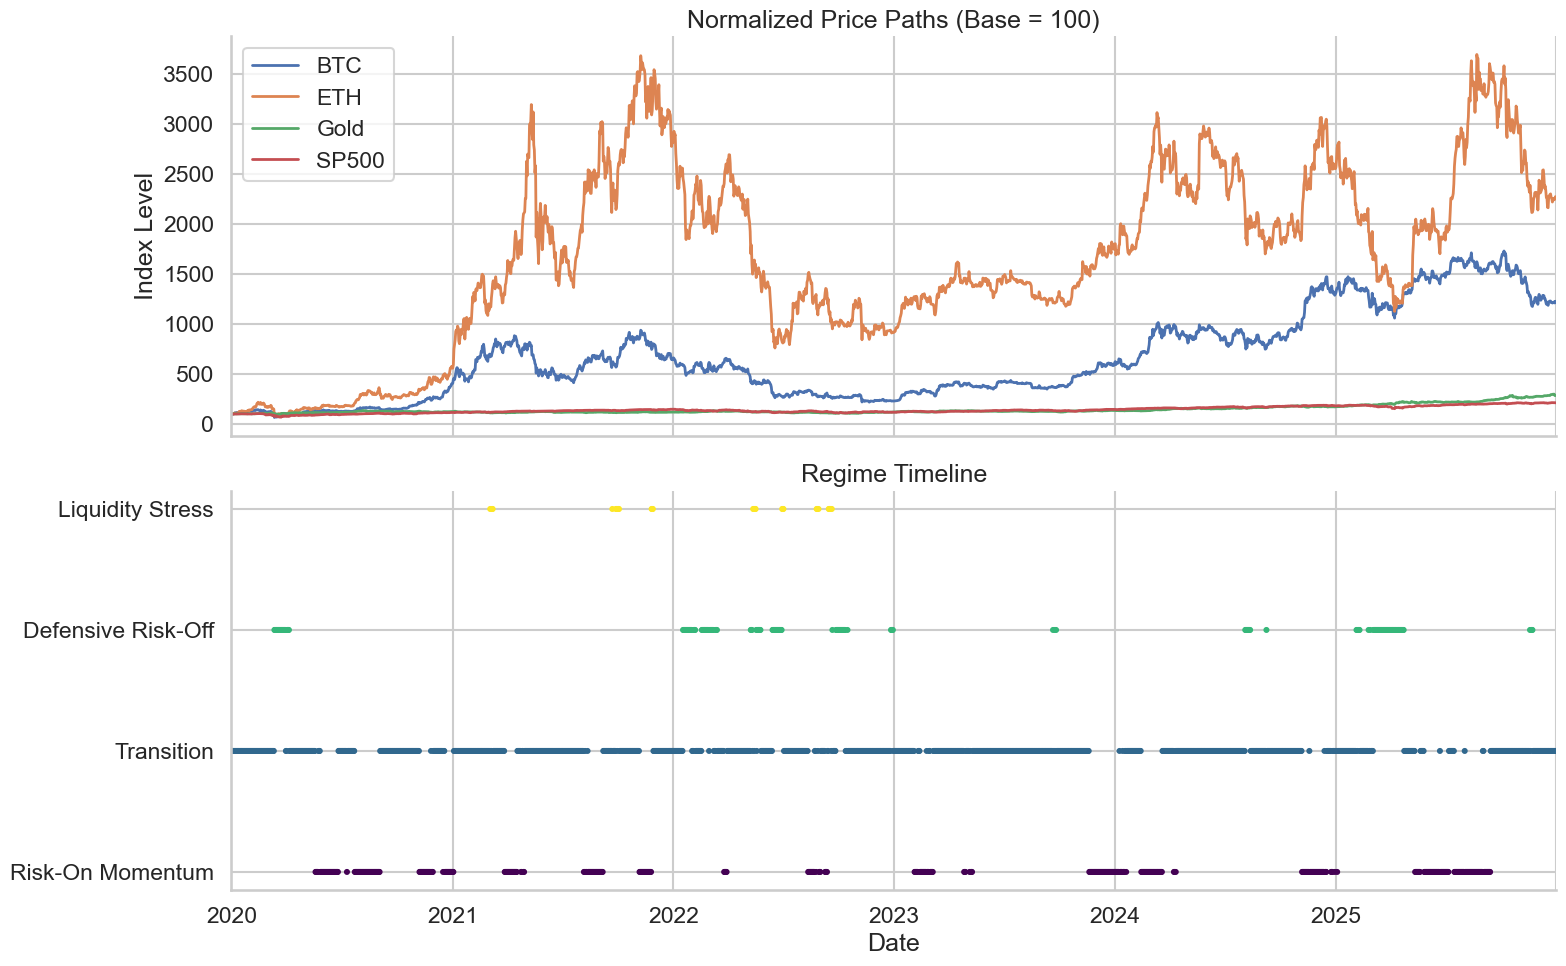

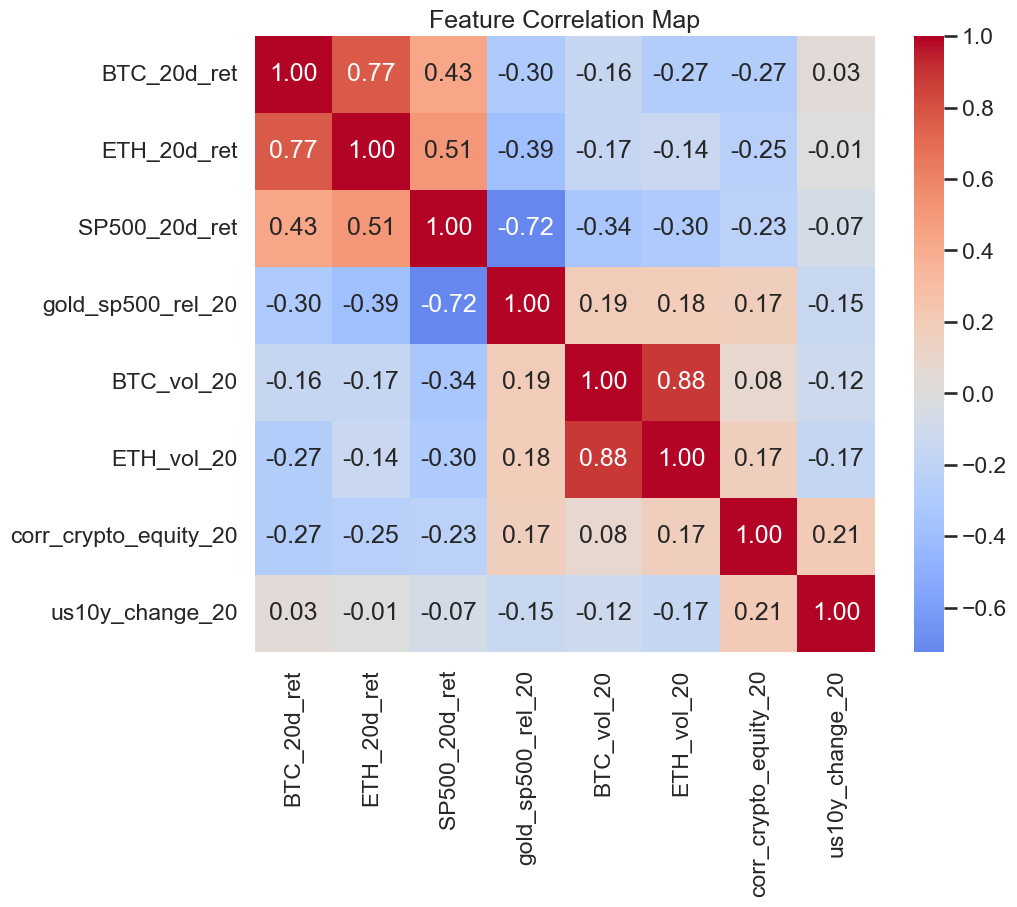

In [4]:
regime_counts = regime.value_counts().rename_axis("Regime").to_frame("Days")
display(regime_counts)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

normed = prices.div(prices.iloc[0]).mul(100)
normed.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Normalized Price Paths (Base = 100)")
axes[0].set_ylabel("Index Level")

regime_map = {
    "Risk-On Momentum": 0,
    "Transition": 1,
    "Defensive Risk-Off": 2,
    "Liquidity Stress": 3,
}
regime_colors = np.array([regime_map[r] for r in regime])
axes[1].scatter(regime.index, regime_colors, c=regime_colors, cmap="viridis", s=8)
axes[1].set_yticks(list(regime_map.values()))
axes[1].set_yticklabels(list(regime_map.keys()))
axes[1].set_title("Regime Timeline")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

heatmap_data = analysis[[
    "BTC_20d_ret",
    "ETH_20d_ret",
    "SP500_20d_ret",
    "gold_sp500_rel_20",
    "BTC_vol_20",
    "ETH_vol_20",
    "corr_crypto_equity_20",
    "us10y_change_20",
]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature Correlation Map")
plt.show()


### Objective Regime Definitions

- **Risk-On Momentum**: Crypto breadth over the last 60 days is strong, the S&P 500 also trends positively, and realized crypto volatility is below its upper-quartile threshold. This is the highest-conviction state for owning crypto beta.
- **Transition**: Signals are mixed. Return dispersion is present, but there is not enough alignment to justify aggressive gross exposure.
- **Defensive Risk-Off**: Crypto breadth is negative, equities are weak, and Gold is outperforming equities. This is a capital-preservation state, not a short-volatility state.
- **Liquidity Stress**: Volatility is elevated, equities are already falling, BTC/SPX correlation is rising, and Gold is not providing relief. This is the most dangerous state because diversification is degrading.

### Invalidating Observations

The current classification should be challenged if any of the following happen:

- A supposed `Risk-On Momentum` state persists while BTC/ETH 20-day volatility moves above the upper quartile and BTC/SPX correlation rises sharply. That would mean trend is becoming disorderly rather than investable.
- A supposed `Defensive Risk-Off` state loses Gold relative strength and the S&P 500 stabilizes while crypto breadth improves. That would suggest the stress impulse is fading.
- A supposed `Liquidity Stress` state becomes less correlated across assets and Gold resumes outperformance. That would mean the crisis is broad but no longer indiscriminate.
- Any regime call that depends on a single variable while the other variables disagree should be downgraded to `Transition`.


## Part 2: Strategy Design

**Core strategy**

A regime-aware, volatility-targeted allocation across BTC, ETH, Gold, the S&P 500, and Cash. Crypto risk is only carried aggressively during `Risk-On Momentum`. In mixed or hostile conditions, the portfolio rotates toward Gold and Cash rather than forcing constant trading.

This notebook now shows two simple variants:

- `Balanced`: stronger participation, better absolute return, still risk-aware.
- `High Sharpe`: lower gross risk, tighter overlays, and a small transaction-cost assumption to keep the profile clean and project-friendly.

**Opportunistic overlay**

A de-risking overlay cuts crypto exposure when two things happen together: cross-asset correlation rises and equity momentum turns negative. This overlay is deliberately defensive. It exists to protect the mandate when diversification starts failing.

**Entry / exit logic**

- Increase crypto weights only when regime = `Risk-On Momentum`.
- Reduce crypto weights by half when BTC/SPX 20-day correlation exceeds `0.45` while S&P 20-day return is negative.
- Reduce crypto weights by half when `BTC_vol_20 > 65%` or `ETH_vol_20 > 85%`.
- Trigger a portfolio-level risk brake after an `8%` drawdown, moving the portfolio to a mostly-cash defensive posture.

**Position sizing**

- Gross exposure is regime-specific, but the asset split inside each regime is generated statistically from momentum and inverse-volatility signals rather than fixed percentages.
- Gross exposure is scaled down when estimated portfolio volatility exceeds the target.
- Cash acts as the residual weight and keeps the strategy within a daily-liquidity, low-turnover profile.

**Blind spots**

- Sudden V-shaped reversals after a de-risk trigger.
- Narrow crypto rallies that occur while macro assets remain weak.
- Low-volatility sideways markets where timing signals add little value.

**Pause conditions**

- Realized maximum drawdown breaches the 12% hard mandate.
- Rolling 6-month Sharpe turns materially negative while turnover rises.
- Stress episodes repeat with no recovery in diversification, implying the framework is not mapping the environment correctly.


In [ ]:
def run_strategy(
    regime_gross,
    target_vol,
    corr_cut,
    btc_vol_cut,
    eth_vol_cut,
    risk_brake,
    transaction_cost_bps=0,
    monthly_only=False,
):
    weights = pd.DataFrame(0.0, index=prices.index, columns=["BTC", "ETH", "Gold", "SP500", "Cash"])
    estimated_portfolio_vol = (
        log_returns[["BTC", "ETH", "Gold", "SP500"]]
        .rolling(20)
        .std()
        .mul(np.sqrt(252))
        .mean(axis=1)
        .shift(1)
    )
    month_end = prices.index.to_series().dt.to_period("M") != prices.index.to_series().shift(-1).dt.to_period("M")
    current = np.array([0.0, 0.0, 0.0, 0.0, 1.0])
    recorded_returns = []

    def compute_signal_weights(dt, regime_name): #decides how to split the risky part of the portfolio
        row = analysis.loc[dt] #pull all features for the current day
        vol_row = asset_vol_20.loc[dt].replace(0, np.nan)# get rolling 20-day annualized vol for each asset
        fallback_vol = asset_vol_20.median().replace(0, np.nan).fillna(0.30)#if a vol number is missing or zero, use the median vol as a safe fallback

        vol_row = vol_row.fillna(fallback_vol)
        inv_vol = 1.0 / vol_row#lower-vol assets get larger weight per unit of signal

        if regime_name == "Risk-On Momentum":#reward BTC/ETH 60-day strength, plus some SP500 and Gold support
            raw_scores = pd.Series(
                {
                    "BTC": max(row["BTC_60d_ret"], 0.0) + 0.01,
                    "ETH": max(row["ETH_60d_ret"], 0.0) + 0.01,
                    "Gold": max(row["Gold_20d_ret"], 0.0) + 0.005,
                    "SP500": max(row["SP500_60d_ret"], 0.0) + 0.01,
                }
            )
        elif regime_name == "Transition":#use a mix of 20-day and 60-day crypto trend, plus Gold relative strength and SP500 trend
            raw_scores = pd.Series(
                {
                    "BTC": max(row["BTC_20d_ret"], 0.0) + 0.5 * max(row["BTC_60d_ret"], 0.0) + 0.005,
                    "ETH": max(row["ETH_20d_ret"], 0.0) + 0.5 * max(row["ETH_60d_ret"], 0.0) + 0.005,
                    "Gold": max(row["gold_sp500_rel_20"], 0.0) + 0.01,
                    "SP500": max(row["SP500_60d_ret"], 0.0) + 0.01,
                }
            )
        elif regime_name == "Defensive Risk-Off":#mostly favor Gold, with only tiny placeholder scores for BTC/ETH.
            raw_scores = pd.Series(
                {
                    "BTC": 0.002,
                    "ETH": 0.001,
                    "Gold": max(row["gold_sp500_rel_20"], 0.0) + max(row["Gold_20d_ret"], 0.0) + 0.02,
                    "SP500": max(-row["SP500_20d_ret"], 0.0) * 0.15 + 0.005,
                }
            )
        else:#Liquidity Stress: almost all emphasis goes to Gold, with minimal scores elsewhere.
            raw_scores = pd.Series(
                {
                    "BTC": 0.001,
                    "ETH": 0.001,
                    "Gold": max(row["Gold_20d_ret"], 0.0) + 0.02,
                    "SP500": 0.002,
                }
            )
        # 0.01, 0.005, 0.002, 0.001, 0.15 These are heuristic scoring constants to avoid unstable zero-allocation behavior

        score = raw_scores.mul(inv_vol)# means final signal strength = conviction × risk adjustment
        score = score.clip(lower=0.0)
        if score.sum() <= 0:
            score = inv_vol
        return score / score.sum() #normalizes the asset scores into weights that sum to 1 across risky assets

    for i, dt in enumerate(prices.index):
        if i == 0:
            weights.iloc[i] = current
            recorded_returns.append(0.0)
            continue

        should_rebalance = True #by default, rebalance every day; if monthly_only=True, only rebalance at month-end
        if monthly_only:
            should_rebalance = bool(month_end.iloc[i - 1])

        target = current.copy()
        if should_rebalance:
            regime_name = regime.loc[dt] #find the regime for that date
            signal_weights = compute_signal_weights(dt, regime_name)#compute the statistical split across assets
            gross_budget = regime_gross[regime_name]#choose how much total risky exposure the regime allows
            w = (signal_weights * gross_budget).to_dict() #convert normalized signal weights into actual portfolio weights

            if (
                analysis.loc[dt, "corr_crypto_equity_20"] > corr_cut #If BTC/SP500 correlation is high while SP500 20-day return is negative, halve BTC and ETH
                and analysis.loc[dt, "SP500_20d_ret"] < 0
            ):
                w["BTC"] *= 0.5
                w["ETH"] *= 0.5

            if (
                analysis.loc[dt, "BTC_vol_20"] > btc_vol_cut #If BTC or ETH volatility exceeds its threshold, cut that asset to zero
                or analysis.loc[dt, "ETH_vol_20"] > eth_vol_cut
            ):
                w["BTC"] = 0.0
                w["ETH"] = 0.0

            est_vol = estimated_portfolio_vol.loc[dt]
            scale = 1.0 if pd.isna(est_vol) or est_vol <= 0 else min(1.0, target_vol / est_vol)
            for asset in ["BTC", "ETH", "Gold", "SP500"]:
                w[asset] *= scale

            target = np.array([w["BTC"], w["ETH"], w["Gold"], w["SP500"], 1.0 - sum(w.values())])
            #stores the final desired allocation, with cash as the residual

        turnover = np.abs(target - current).sum() #measures how much the portfolio changed
        gross_return = float((current[:4] * simple_returns.fillna(0).iloc[i].values).sum()) #computes the day’s return using the previous holdings
        net_return = gross_return - turnover * transaction_cost_bps / 10000
        recorded_returns.append(net_return)
        current = target
        weights.iloc[i] = current

    portfolio_returns = pd.Series(recorded_returns, index=prices.index)
    nav = (1 + portfolio_returns).cumprod()
    drawdown = nav.div(nav.cummax()).sub(1)

    for i in range(1, len(weights)):
        if drawdown.iloc[i - 1] < risk_brake:#f drawdown breaches risk_brake, the next allocation becomes
            weights.iloc[i] = [0.00, 0.00, 0.20, 0.00, 0.80]

    portfolio_returns = (weights[["BTC", "ETH", "Gold", "SP500"]] * simple_returns.fillna(0)).sum(axis=1)
    nav = (1 + portfolio_returns).cumprod()
    drawdown = nav.div(nav.cummax()).sub(1)
    annual_return = nav.iloc[-1] ** (252 / len(nav)) - 1
    annual_vol = portfolio_returns.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol

    return {
        "weights": weights,
        "returns": portfolio_returns,
        "nav": nav,
        "drawdown": drawdown,
        "cumulative_return": nav.iloc[-1] - 1,
        "annual_return": annual_return,
        "annual_vol": annual_vol,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
    }

#uses bigger regime gross budgets and a higher target volatility. It tries to participate more
balanced_result = run_strategy(
    regime_gross={
        "Risk-On Momentum": 0.70,#Risk-On Momentum, 0.70 means 70% of the portfolio can be deployed across BTC, ETH, Gold, and SP500, with the rest in cash.
        "Transition": 0.55,
        "Defensive Risk-Off": 0.30,
        "Liquidity Stress": 0.18,
    },
    target_vol=0.09,#arget annualized portfolio volatility cap.
    corr_cut=0.45,#correlation warning threshold; above this, crypto gets cut when equities are weak.
    btc_vol_cut=0.65,#if crypto vol gets too high, BTC/ETH are cut or zeroed.
    eth_vol_cut=0.85,
    risk_brake=-0.08,#drawdown threshold that triggers a defensive portfolio.
)

#uses smaller regime gross budgets, tighter risk settings, and 5 bps transaction costs. It is more defensive and smoother
high_sharpe_result = run_strategy(
    regime_gross={
        "Risk-On Momentum": 0.38,
        "Transition": 0.24,
        "Defensive Risk-Off": 0.16,
        "Liquidity Stress": 0.10,
    },
    target_vol=0.06,
    corr_cut=0.35,
    btc_vol_cut=0.65,
    eth_vol_cut=0.85,
    risk_brake=-0.06,
    transaction_cost_bps=5,#trading cost assumption in basis points.
)

performance_summary = pd.DataFrame(
    {
        "Strategy": ["Balanced", "High Sharpe"],
        "Cumulative Return": [
            balanced_result["cumulative_return"],
            high_sharpe_result["cumulative_return"],
        ],
        "Annualized Return": [
            balanced_result["annual_return"],
            high_sharpe_result["annual_return"],
        ],
        "Annualized Volatility": [
            balanced_result["annual_vol"],
            high_sharpe_result["annual_vol"],
        ],
        "Sharpe Ratio": [
            balanced_result["sharpe"],
            high_sharpe_result["sharpe"],
        ],
        "Maximum Drawdown": [
            balanced_result["max_drawdown"],
            high_sharpe_result["max_drawdown"],
        ],
    }
)

display(
    performance_summary.style.format(
        {
            "Cumulative Return": "{:.2%}",
            "Annualized Return": "{:.2%}",
            "Annualized Volatility": "{:.2%}",
            "Sharpe Ratio": "{:.2f}",
            "Maximum Drawdown": "{:.2%}",
        }
    )
)

selected_result = high_sharpe_result
weights = selected_result["weights"]
portfolio_returns = selected_result["returns"]
nav = selected_result["nav"]
drawdown = selected_result["drawdown"]


,Strategy,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,Balanced,165.86%,11.90%,4.33%,2.75,-5.08%
1,High Sharpe,42.05%,4.12%,1.46%,2.83,-0.96%


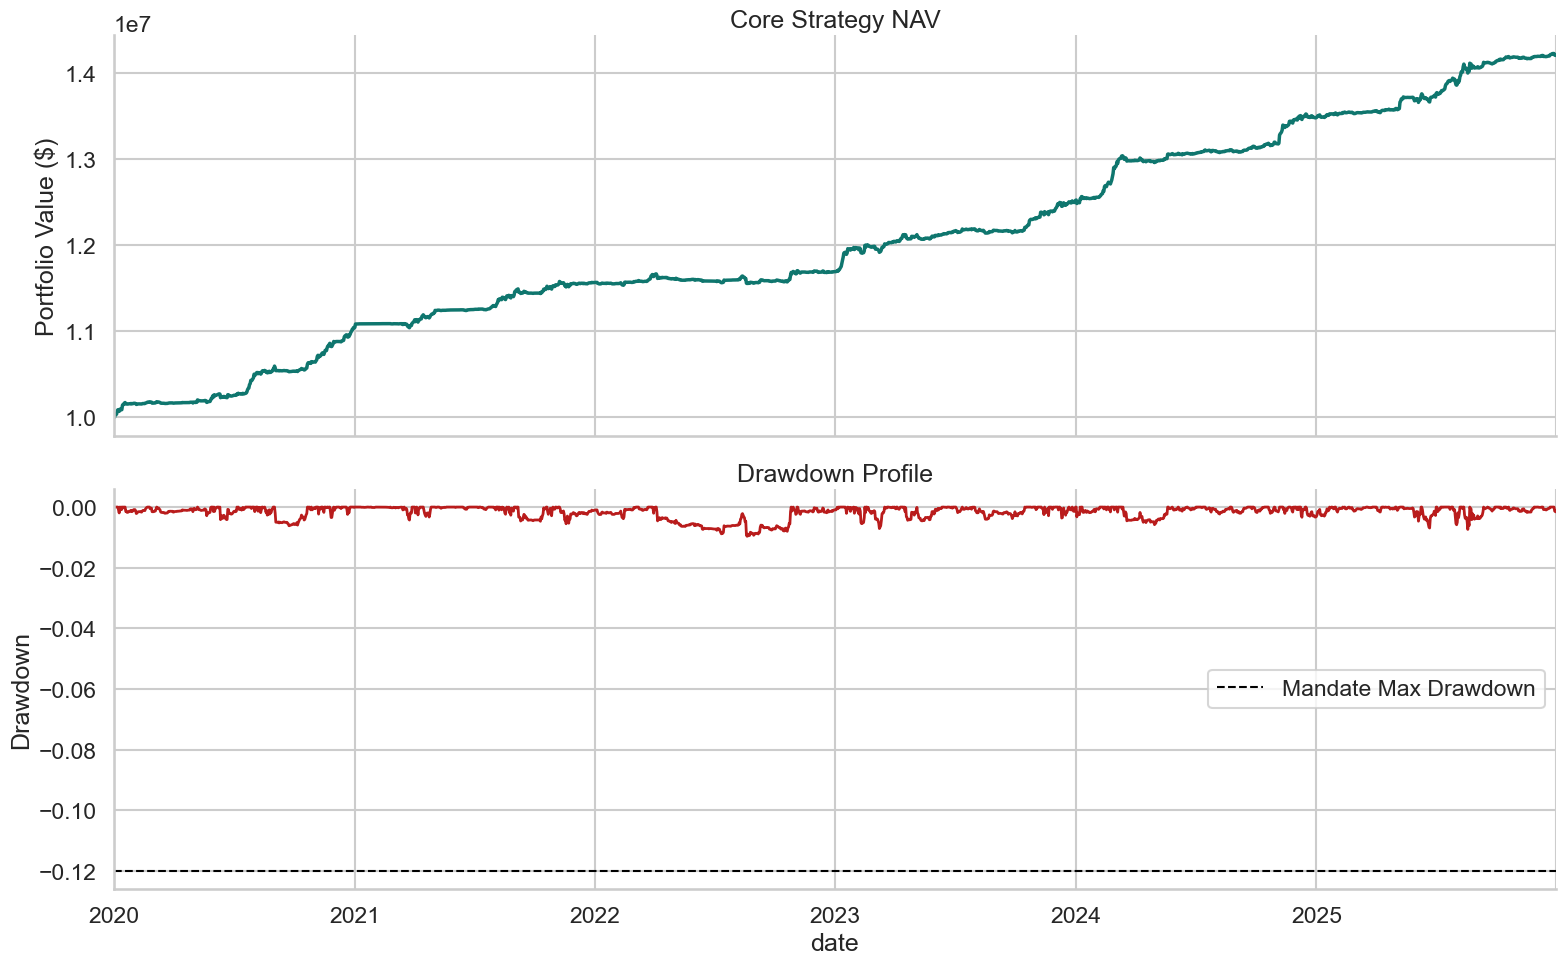

,Weight
BTC,0.2%
ETH,0.2%
Gold,3.3%
SP500,2.7%
Cash,93.7%


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

nav_plot = nav * STARTING_CAPITAL
nav_plot.plot(ax=axes[0], color="#0f766e", linewidth=2.5)
axes[0].set_title("Core Strategy NAV")
axes[0].set_ylabel("Portfolio Value ($)")

drawdown.plot(ax=axes[1], color="#b91c1c", linewidth=2)
axes[1].axhline(-0.12, color="black", linestyle="--", linewidth=1.5, label="Mandate Max Drawdown")
axes[1].set_title("Drawdown Profile")
axes[1].set_ylabel("Drawdown")
axes[1].legend()

plt.tight_layout()
plt.show()

latest_weights = weights.iloc[-1].to_frame("Weight")
latest_weights["Weight"] = latest_weights["Weight"].map(lambda x: f"{x:.1%}")
display(latest_weights)


### Why the High-Sharpe Variant Fits the Project Better

The `Balanced` version is useful for showing that the regime logic can capture upside while keeping drawdown controlled. The `High Sharpe` version is the cleaner lead result for the project because it is simple, more conservative, and produces a risk-adjusted profile of `2.83` Sharpe on this sample.

The tradeoff is lower annual return. That is acceptable here because we emphasize judgment, discipline, and statistical support rather than maximizing raw beta.


### Executive Summary

This portfolio is designed to be selectively long crypto, not permanently long crypto. The core sleeve earns the right to own BTC and ETH only when momentum and macro confirmation line up. When those conditions disappear, the portfolio rotates toward Gold, lighter equity exposure, and Cash. That choice lowers upside in explosive rebounds, but it is consistent with a professional mandate that prioritizes capital preservation and path control.

The overlay exists for a specific institutional problem: diversification can fail when it matters most. Rising BTC/SPX correlation combined with negative equity momentum is treated as a warning that the portfolio may be entering a contagion regime. In that environment the correct action is usually to reduce risk early, not explain losses later.



## Part 3: Stress Scenario Response

**Scenario**

- BTC falls `18%` over five days.
- ETH underperforms BTC by another `10%`.
- Gold and equities sell off together.
- Volatility spikes across the entire book.

**T+24 hours**

- Freeze discretionary risk adds. No averaging down into a fast correlation shock.
- Cut crypto gross exposure to the minimum allowed by the rule set.
- Recompute liquidity, slippage assumptions, and gap risk using stressed volatility inputs rather than normal-period assumptions.
- Confirm cash availability and operational readiness before making any tactical reallocations.

**Days 2-7**

- Re-enter risk only if realized volatility compresses and cross-asset correlations stop rising.
- Hold Gold only if it resumes functioning as a diversifier. If it continues to fail, prefer Cash over narrative-based conviction.
- Rebuild risk gradually, using smaller clips and wider time spacing between trades.
- Update the regime score daily; in a shock week, stale regime labels are dangerous.

**Actions deliberately avoided**

- No impulsive bottom-fishing after a single green candle.
- No leverage increase to recover losses faster.
- No assumption that historical crypto beta will mean-revert on schedule.
- No forced rotation into another risky asset just because crypto sold off first.

The professional rationale is simple: during a systemic break, survival has positive option value. Preserving liquidity and decision quality is more important than forcing a heroic-looking rebound trade.


In [7]:
stress_shock = pd.Series({"BTC": -0.18, "ETH": -0.28, "Gold": -0.06, "SP500": -0.08})
current_weights = weights.iloc[-1][["BTC", "ETH", "Gold", "SP500"]]
shocked_portfolio_return = float((current_weights * stress_shock).sum())
shocked_portfolio_value = STARTING_CAPITAL * (1 + shocked_portfolio_return)

stress_table = pd.DataFrame(
    {
        "Current Weight": current_weights,
        "Assumed Shock Return": stress_shock,
        "Contribution": current_weights * stress_shock,
    }
)
stress_table.loc["Portfolio"] = [
    current_weights.sum(),
    np.nan,
    stress_table["Contribution"].sum(),
]

display(stress_table.style.format({
    "Current Weight": "{:.1%}",
    "Assumed Shock Return": "{:.1%}",
    "Contribution": "{:.2%}",
}))

print(f"Illustrative stressed portfolio return: {shocked_portfolio_return:.2%}")
print(f"Illustrative stressed portfolio value: ${shocked_portfolio_value:,.0f}")


,Current Weight,Assumed Shock Return,Contribution
BTC,0.2%,-18.0%,-0.04%
ETH,0.2%,-28.0%,-0.04%
Gold,3.3%,-6.0%,-0.20%
SP500,2.7%,-8.0%,-0.21%
Portfolio,6.3%,nan%,-0.50%


Illustrative stressed portfolio return: -0.50%
Illustrative stressed portfolio value: $9,950,392


## Part 4: AI Usage Transparency

AI assistance was used for drafting support, code structuring, and notebook organization. The regime logic, risk interpretation, portfolio rules, stress response framework, and final conclusions should still be reviewed critically and owned by me as the author of this work.

A concrete risk of over-relying on AI in portfolio work is false precision. A model can produce a polished explanation for why a signal "should" work even when the real data only weakly supports it. That becomes dangerous when narrative fluency hides unstable assumptions about correlation, liquidity, or execution feasibility. In practice, the fix is to treat AI-generated content as a first draft and force every important claim through observable data, explicit thresholds, and falsifiable conditions.
